# 04b_Candidate_Validation_PreDocking_EnergeticHotspots.ipynb

## PEARL — candidate validation before docking, guided by FoldX energetic hotspots

This notebook updates the previous `04_Candidate_Validation_PreDocking` workflow.

Main change:

> Candidate validation now uses **FoldX-derived energetic hotspots** from alanine scanning, instead of graph-proxy hotspot-like residues.

Expected upstream notebooks:

```text
01_EGFR_PDB_to_Interface_Graph.ipynb
02b_Interface_Hotspot_AlanineScanning_FoldX.ipynb
03b_Contiguous_Peptide_Window_Diffusion_EnergeticHotspots.ipynb
```

Expected inputs:

```text
outputs/diffusion_energetic_peptide_candidates.csv
outputs/diffusion_contiguous_peptide_candidates.csv
outputs/selected_energetic_seed_metadata.csv
outputs/selected_energetic_seed_window.csv
outputs/interface_residues_with_foldx_ddg.csv
outputs/energetic_hotspots.csv
```

Expected outputs:

```text
outputs/validated_candidates_pre_docking_energetic.csv
outputs/top_diffusion_energetic_peptides_summary.csv
outputs/top_diffusion_energetic_peptides_pre_docking.fasta
outputs/candidate_mutations_energetic_long_format.csv
outputs/pre_docking_energetic_validation_report.md
outputs/position_mutation_profile_energetic.csv
```

Scientific interpretation:

- This notebook provides **pre-docking prioritization**, not binding validation.
- Mutations on FoldX energetic hotspots are strongly penalized.
- Candidates are selected for downstream structural validation, e.g. ESMFold/ColabFold, docking, MD, or MM-GBSA/MM-PBSA.


## 0. Setup

In [1]:
from pathlib import Path
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED_RANDOM = 42
random.seed(SEED_RANDOM)
np.random.seed(SEED_RANDOM)

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

NL = chr(10)

PEPTIDE_CHAIN = "D"
DDG_HOTSPOT_THRESHOLD = 1.5

print("Output directory:", OUTPUT_DIR.resolve())


Output directory: /Users/robertobruzzese/Desktop/venv/outputs


## 1. Load energetic diffusion candidates and seed metadata

In [2]:
# Prefer the energetic candidate file produced by 03b.
CANDIDATES_ENERGETIC_PATH = OUTPUT_DIR / "diffusion_energetic_peptide_candidates.csv"
CANDIDATES_COMPAT_PATH = OUTPUT_DIR / "diffusion_contiguous_peptide_candidates.csv"

SEED_META_PATH = OUTPUT_DIR / "selected_energetic_seed_metadata.csv"
SEED_WINDOW_PATH = OUTPUT_DIR / "selected_energetic_seed_window.csv"
INTERFACE_DDG_PATH = OUTPUT_DIR / "interface_residues_with_foldx_ddg.csv"
ENERGETIC_HOTSPOTS_PATH = OUTPUT_DIR / "energetic_hotspots.csv"

if CANDIDATES_ENERGETIC_PATH.exists():
    CANDIDATES_PATH = CANDIDATES_ENERGETIC_PATH
else:
    CANDIDATES_PATH = CANDIDATES_COMPAT_PATH

print("Candidates path:", CANDIDATES_PATH)
print("Seed metadata exists:", SEED_META_PATH.exists(), SEED_META_PATH)
print("Interface ΔΔG table exists:", INTERFACE_DDG_PATH.exists(), INTERFACE_DDG_PATH)

if not CANDIDATES_PATH.exists():
    raise FileNotFoundError(
        "Missing diffusion candidates. Run 03b_Contiguous_Peptide_Window_Diffusion_EnergeticHotspots.ipynb first."
    )

if not SEED_META_PATH.exists():
    raise FileNotFoundError(
        "Missing selected_energetic_seed_metadata.csv. Run 03b_Contiguous_Peptide_Window_Diffusion_EnergeticHotspots.ipynb first."
    )

candidates = pd.read_csv(CANDIDATES_PATH)
seed_meta = pd.read_csv(SEED_META_PATH)
seed_window = pd.read_csv(SEED_WINDOW_PATH) if SEED_WINDOW_PATH.exists() else pd.DataFrame()
interface_ddg = pd.read_csv(INTERFACE_DDG_PATH) if INTERFACE_DDG_PATH.exists() else pd.DataFrame()
energetic_hotspots = pd.read_csv(ENERGETIC_HOTSPOTS_PATH) if ENERGETIC_HOTSPOTS_PATH.exists() else pd.DataFrame()

print("candidates shape:", candidates.shape)
print("seed_meta shape:", seed_meta.shape)
print("interface_ddg shape:", interface_ddg.shape)
print("energetic_hotspots shape:", energetic_hotspots.shape)

display(candidates.head())
display(seed_meta.head())
display(seed_window.head())


Candidates path: outputs/diffusion_energetic_peptide_candidates.csv
Seed metadata exists: True outputs/selected_energetic_seed_metadata.csv
Interface ΔΔG table exists: True outputs/interface_residues_with_foldx_ddg.csv
candidates shape: (239, 16)
seed_meta shape: (30, 26)
interface_ddg shape: (74, 17)
energetic_hotspots shape: (15, 17)


,sequence,is_seed,length,score,energetic_hotspot_preservation,hotspot_preservation,interface_exact_preservation,interface_group_similarity,global_group_similarity,normalized_hamming,novelty_bonus,composition_penalty,seed_start_resseq,seed_end_resseq,n_energetic_hotspots_in_seed,n_interface_positions_in_seed
0,MYIDALEKFACNCMVPYIGERCQYRDLKWW,False,30,0.971399,1.0,1.0,1.000000,1.0,1.0,0.166667,0.856997,0.0,21,50,11,23
1,MFIDALDKFACSCVVPYIGERCQYRDLKWW,False,30,0.964878,1.0,1.0,0.956522,1.0,1.0,0.166667,0.856997,0.0,21,50,11,23
2,MWIDALDKWACNCVVPYVGERCQYRDLKWW,False,30,0.964878,1.0,1.0,0.956522,1.0,1.0,0.166667,0.856997,0.0,21,50,11,23
3,MYIDALDKWACNCAVPYIGERCQYRDLKWW,False,30,0.947798,1.0,1.0,1.000000,1.0,1.0,0.133333,0.738991,0.0,21,50,11,23
4,MYIDALEKWACNCIVGYIGERCQYRDLKWW,False,30,0.947798,1.0,1.0,1.000000,1.0,1.0,0.133333,0.738991,0.0,21,50,11,23


,chain,resseq,icode,resname,aa,x,y,z,pos_full,resname_foldx,...,has_foldx_ddg,is_energetic_hotspot,is_graph_proxy_hotspot_like,is_interface,contacts_receptor_energetic_hotspot,n_contacted_receptor_energetic_hotspots,contacted_receptor_hotspot_ddG_sum,contacted_receptor_hotspots,is_energetic_design_anchor,pos_seed
0,D,21,NaN,MET,M,37.652000,36.233002,42.422001,16,MET,...,True,True,False,True,False,0,0.0,NaN,True,0
1,D,22,NaN,TYR,Y,37.851002,37.646000,38.903999,17,NaN,...,False,False,False,False,False,0,0.0,NaN,False,1
2,D,23,NaN,ILE,I,38.068001,41.426998,38.708000,18,ILE,...,True,True,False,True,False,0,0.0,NaN,True,2
3,D,24,NaN,GLU,E,36.394001,42.117001,35.360001,19,NaN,...,False,False,False,False,False,0,0.0,NaN,False,3
4,D,25,NaN,ALA,A,36.980999,45.825001,35.945000,20,ALA,...,True,False,False,True,False,0,0.0,NaN,False,4


,start_pos_full,end_pos_full,start_resseq,end_resseq,length,sequence,n_interface_residues,n_peptide_energetic_hotspots,n_receptor_hotspot_contact_anchors,n_energetic_design_anchors,peptide_ddG_sum_kcal_mol,receptor_contact_ddG_sum_kcal_mol,graph_proxy_sum,contact_sum,energetic_window_score,selection_rule
0,16,45,21,50,30,MYIEALDKYACNCVVGYIGERCQYRDLKWW,23,11,0,11,47.588652,0.0,6.182353,68.0,273.753983,best_window_covering_foldx_energetic_design_an...


## 2. Recover the energetic seed sequence

In [3]:
if "is_seed" not in candidates.columns:
    raise ValueError("The candidates table must contain an is_seed column.")

seed_rows = candidates[candidates["is_seed"] == True].copy()
if seed_rows.empty:
    raise ValueError("No seed row found in candidates table.")

seed_sequence = str(seed_rows.iloc[0]["sequence"])
seed_meta["pos_seed"] = seed_meta["pos_seed"].astype(int)

reconstructed_seed = "".join(seed_meta.sort_values("pos_seed")["aa"].astype(str).tolist())

print("Seed sequence from candidates:")
print(seed_sequence)
print("Reconstructed seed from metadata:")
print(reconstructed_seed)
print("Match:", seed_sequence == reconstructed_seed)

if seed_sequence != reconstructed_seed:
    raise ValueError("Seed sequence does not match selected_energetic_seed_metadata.csv.")

SEED_START_RESSEQ = int(seed_meta["resseq"].min())
SEED_END_RESSEQ = int(seed_meta["resseq"].max())

print("Seed interval:", f"{PEPTIDE_CHAIN}:{SEED_START_RESSEQ}-{SEED_END_RESSEQ}")
print("Seed length:", len(seed_sequence))

display(seed_rows)


Seed sequence from candidates:
MYIEALDKYACNCVVGYIGERCQYRDLKWW
Reconstructed seed from metadata:
MYIEALDKYACNCVVGYIGERCQYRDLKWW
Match: True
Seed interval: D:21-50
Seed length: 30


,sequence,is_seed,length,score,energetic_hotspot_preservation,hotspot_preservation,interface_exact_preservation,interface_group_similarity,global_group_similarity,normalized_hamming,novelty_bonus,composition_penalty,seed_start_resseq,seed_end_resseq,n_energetic_hotspots_in_seed,n_interface_positions_in_seed
233,MYIEALDKYACNCVVGYIGERCQYRDLKWW,True,30,0.84987,1.0,1.0,1.0,1.0,1.0,0.0,0.249352,0.0,21,50,11,23


## 3. Validate energetic-hotspot annotations

The key PEARL-compliant column is:

```text
is_energetic_hotspot
```

This should come from FoldX alanine scanning with:

```text
ΔΔG > 1.5 kcal/mol
```


In [4]:
required_seed_cols = {"pos_seed", "resseq", "aa", "is_interface", "ddG_kcal_mol", "is_energetic_hotspot"}
missing = required_seed_cols - set(seed_meta.columns)
if missing:
    raise ValueError(f"Missing required columns in seed_meta: {missing}")

seed_meta["is_energetic_hotspot"] = seed_meta["is_energetic_hotspot"].astype(bool)
seed_meta["is_interface"] = seed_meta["is_interface"].astype(bool)
seed_meta["ddG_kcal_mol"] = seed_meta["ddG_kcal_mol"].fillna(0.0)

if "graph_proxy_score" not in seed_meta.columns:
    seed_meta["graph_proxy_score"] = 0.0
if "is_graph_proxy_hotspot_like" not in seed_meta.columns:
    seed_meta["is_graph_proxy_hotspot_like"] = False

seed_meta["is_graph_proxy_hotspot_like"] = seed_meta["is_graph_proxy_hotspot_like"].fillna(False).astype(bool)

energetic_hotspot_positions = set(
    seed_meta.loc[seed_meta["is_energetic_hotspot"], "pos_seed"].astype(int).tolist()
)
interface_positions = set(
    seed_meta.loc[seed_meta["is_interface"], "pos_seed"].astype(int).tolist()
)
graph_proxy_positions = set(
    seed_meta.loc[seed_meta["is_graph_proxy_hotspot_like"], "pos_seed"].astype(int).tolist()
)

print("Energetic hotspot positions:", sorted(energetic_hotspot_positions))
print("Interface positions:", sorted(interface_positions))
print("Graph-proxy hotspot-like positions:", sorted(graph_proxy_positions))
print("Number of energetic hotspots:", len(energetic_hotspot_positions))

if len(energetic_hotspot_positions) == 0:
    raise RuntimeError(
        "No energetic hotspots found in the selected seed. "
        "This notebook is intended for FoldX-guided validation. "
        "Check 02b/03b outputs before continuing."
    )

display(
    seed_meta.sort_values(["is_energetic_hotspot", "ddG_kcal_mol"], ascending=[False, False])
    [["pos_seed", "resseq", "aa", "is_interface", "ddG_kcal_mol", "is_energetic_hotspot", "graph_proxy_score"]]
)


Energetic hotspot positions: [0, 2, 5, 12, 16, 18, 20, 22, 23, 24, 26]
Interface positions: [0, 2, 4, 5, 7, 9, 10, 11, 12, 14, 16, 17, 18, 19, 20, 22, 23, 24, 25, 26, 27, 28, 29]
Graph-proxy hotspot-like positions: [5, 12, 17, 19, 20, 23, 26]
Number of energetic hotspots: 11


,pos_seed,resseq,aa,is_interface,ddG_kcal_mol,is_energetic_hotspot,graph_proxy_score
18,18,39,G,True,5.876590,True,0.160235
20,20,41,R,True,5.734550,True,0.442780
16,16,37,Y,True,4.645860,True,0.129714
5,5,26,L,True,4.158520,True,0.458812
2,2,23,I,True,3.656140,True,0.246391
26,26,47,L,True,3.543710,True,0.928566
23,23,44,Y,True,3.370680,True,0.561339
12,12,33,C,True,2.913030,True,0.432145
22,22,43,Q,True,2.515570,True,0.241834
24,24,45,R,True,2.002810,True,0.354894


## 4. Define mutation classes and energetic risk rules

Risk logic:

- mutation on an energetic hotspot: strong penalty;
- non-conservative mutation on interface residue: penalty;
- charge change on interface or energetic hotspot: penalty;
- mutation severity is scaled by FoldX ΔΔG where available.


In [5]:
AA_GROUPS = {
    "aliphatic_hydrophobic": set("AVLIM"),
    "aromatic": set("FWY"),
    "positive": set("KRH"),
    "negative": set("DE"),
    "polar_uncharged": set("STNQ"),
    "special": set("GP"),
    "cysteine": set("C"),
}

AA_TO_GROUP = {}
for group_name, aas in AA_GROUPS.items():
    for aa in aas:
        AA_TO_GROUP[aa] = group_name

CHARGE = {}
for aa in "KRH":
    CHARGE[aa] = "positive"
for aa in "DE":
    CHARGE[aa] = "negative"
for aa in "ACFGILMNPQSTVWY":
    CHARGE[aa] = "neutral"

def aa_group(aa):
    return AA_TO_GROUP.get(aa, "unknown")

def aa_charge(aa):
    return CHARGE.get(aa, "unknown")

def mutation_class(wt, mut):
    if wt == mut:
        return "identical"

    g1 = aa_group(wt)
    g2 = aa_group(mut)

    if g1 == g2:
        return "conservative"

    hydrophobic_like = {"aliphatic_hydrophobic", "aromatic"}
    polar_charge_like = {"positive", "negative", "polar_uncharged"}

    if g1 in hydrophobic_like and g2 in hydrophobic_like:
        return "semi_conservative"
    if g1 in polar_charge_like and g2 in polar_charge_like:
        return "semi_conservative"

    return "non_conservative"

def is_charge_change(wt, mut):
    return aa_charge(wt) != aa_charge(mut)

def energetic_risk_points(row):
    risk = 0.0
    reasons = []

    if row["mutation_class"] == "identical":
        return 0.0, []

    ddg = float(row.get("ddG_kcal_mol", 0.0))

    # Strongest rule: do not alter energetic hotspots.
    if bool(row["is_energetic_hotspot"]):
        risk += 8.0
        risk += max(0.0, ddg - DDG_HOTSPOT_THRESHOLD)
        reasons.append("energetic_hotspot_mutation")

    # Interface-specific risk.
    if bool(row["is_interface"]) and row["mutation_class"] == "non_conservative":
        risk += 4.0
        reasons.append("interface_non_conservative")

    if bool(row["is_interface"]) and bool(row["charge_change"]):
        risk += 3.0
        reasons.append("interface_charge_change")

    # Energetic hotspot charge changes are especially risky.
    if bool(row["is_energetic_hotspot"]) and bool(row["charge_change"]):
        risk += 4.0
        reasons.append("energetic_hotspot_charge_change")

    # Secondary graph-proxy warning, smaller than energetic hotspot.
    if bool(row.get("is_graph_proxy_hotspot_like", False)):
        risk += 1.5
        reasons.append("graph_proxy_hotspot_like_mutation")

    # Simple composition liabilities.
    if row["mut_aa"] == "P" and row["wt_aa"] != "P":
        risk += 2.0
        reasons.append("introduced_proline")
    if row["wt_aa"] == "P" and row["mut_aa"] != "P":
        risk += 1.0
        reasons.append("removed_proline")
    if row["mut_aa"] == "C" and row["wt_aa"] != "C":
        risk += 2.0
        reasons.append("introduced_cysteine")
    if row["wt_aa"] == "C" and row["mut_aa"] != "C":
        risk += 2.0
        reasons.append("removed_cysteine")

    return float(risk), reasons

print("Energetic mutation-risk rules ready.")


Energetic mutation-risk rules ready.


## 5. Build long-format mutation table

In [6]:
mutation_rows = []

seed_meta_sorted = seed_meta.sort_values("pos_seed").reset_index(drop=True)

for cand_idx, row in candidates.iterrows():
    seq = str(row["sequence"])

    if len(seq) != len(seed_sequence):
        print("Skipping sequence with different length:", seq)
        continue

    for pos, (wt, mut) in enumerate(zip(seed_sequence, seq)):
        meta = seed_meta_sorted.iloc[pos]
        mclass = mutation_class(wt, mut)
        charge_changed = is_charge_change(wt, mut)

        mrow = {
            "candidate_index": cand_idx,
            "sequence": seq,
            "is_seed": bool(row["is_seed"]),
            "pos_seed": int(pos),
            "resseq": int(meta["resseq"]),
            "wt_aa": wt,
            "mut_aa": mut,
            "mutation": f"{wt}{int(meta['resseq'])}{mut}" if wt != mut else "",
            "mutation_class": mclass,
            "is_mutated": wt != mut,
            "is_interface": bool(meta["is_interface"]),
            "is_energetic_hotspot": bool(meta["is_energetic_hotspot"]),
            "is_graph_proxy_hotspot_like": bool(meta.get("is_graph_proxy_hotspot_like", False)),
            "ddG_kcal_mol": float(meta["ddG_kcal_mol"]),
            "graph_proxy_score": float(meta.get("graph_proxy_score", 0.0)),
            "n_contacts": float(meta.get("n_contacts", 0.0)),
            "wt_group": aa_group(wt),
            "mut_group": aa_group(mut),
            "wt_charge": aa_charge(wt),
            "mut_charge": aa_charge(mut),
            "charge_change": charge_changed,
        }

        risk_points, reasons = energetic_risk_points(mrow)
        mrow["energetic_risk_points"] = risk_points
        mrow["risk_reasons"] = ";".join(reasons)
        mutation_rows.append(mrow)

mutations_long = pd.DataFrame(mutation_rows)

OUT_MUT_LONG = OUTPUT_DIR / "candidate_mutations_energetic_long_format.csv"
mutations_long.to_csv(OUT_MUT_LONG, index=False)

print("Saved:", OUT_MUT_LONG)
print("mutations_long shape:", mutations_long.shape)
display(mutations_long[mutations_long["is_mutated"]].head(40))


Saved: outputs/candidate_mutations_energetic_long_format.csv
mutations_long shape: (7170, 23)


,candidate_index,sequence,is_seed,pos_seed,resseq,wt_aa,mut_aa,mutation,mutation_class,is_mutated,...,ddG_kcal_mol,graph_proxy_score,n_contacts,wt_group,mut_group,wt_charge,mut_charge,charge_change,energetic_risk_points,risk_reasons
3,0,MYIDALEKFACNCMVPYIGERCQYRDLKWW,False,3,24,E,D,E24D,conservative,True,...,0.000000,0.000000,0.0,negative,negative,negative,negative,False,0.0,
6,0,MYIDALEKFACNCMVPYIGERCQYRDLKWW,False,6,27,D,E,D27E,conservative,True,...,0.000000,0.000000,0.0,negative,negative,negative,negative,False,0.0,
8,0,MYIDALEKFACNCMVPYIGERCQYRDLKWW,False,8,29,Y,F,Y29F,conservative,True,...,0.000000,0.000000,0.0,aromatic,aromatic,neutral,neutral,False,0.0,
13,0,MYIDALEKFACNCMVPYIGERCQYRDLKWW,False,13,34,V,M,V34M,conservative,True,...,0.000000,0.000000,0.0,aliphatic_hydrophobic,aliphatic_hydrophobic,neutral,neutral,False,0.0,
15,0,MYIDALEKFACNCMVPYIGERCQYRDLKWW,False,15,36,G,P,G36P,conservative,True,...,0.000000,0.000000,0.0,special,special,neutral,neutral,False,2.0,introduced_proline
31,1,MFIDALDKFACSCVVPYIGERCQYRDLKWW,False,1,22,Y,F,Y22F,conservative,True,...,0.000000,0.000000,0.0,aromatic,aromatic,neutral,neutral,False,0.0,
33,1,MFIDALDKFACSCVVPYIGERCQYRDLKWW,False,3,24,E,D,E24D,conservative,True,...,0.000000,0.000000,0.0,negative,negative,negative,negative,False,0.0,
38,1,MFIDALDKFACSCVVPYIGERCQYRDLKWW,False,8,29,Y,F,Y29F,conservative,True,...,0.000000,0.000000,0.0,aromatic,aromatic,neutral,neutral,False,0.0,
41,1,MFIDALDKFACSCVVPYIGERCQYRDLKWW,False,11,32,N,S,N32S,conservative,True,...,0.592164,0.085986,2.0,polar_uncharged,polar_uncharged,neutral,neutral,False,0.0,
45,1,MFIDALDKFACSCVVPYIGERCQYRDLKWW,False,15,36,G,P,G36P,conservative,True,...,0.000000,0.000000,0.0,special,special,neutral,neutral,False,2.0,introduced_proline


## 6. Candidate-level energetic validation metrics

In [7]:
def summarize_candidate(group):
    mutated = group[group["is_mutated"]].copy()
    interface_mut = mutated[mutated["is_interface"]]
    energetic_mut = mutated[mutated["is_energetic_hotspot"]]

    n_mut = len(mutated)
    n_interface_mut = len(interface_mut)
    n_energetic_mut = len(energetic_mut)

    n_nonconservative = int((mutated["mutation_class"] == "non_conservative").sum())
    n_interface_nonconservative = int(
        ((mutated["is_interface"]) & (mutated["mutation_class"] == "non_conservative")).sum()
    )
    n_energetic_nonconservative = int(
        ((mutated["is_energetic_hotspot"]) & (mutated["mutation_class"] == "non_conservative")).sum()
    )
    n_charge_changes = int(mutated["charge_change"].sum())
    n_interface_charge_changes = int(((mutated["is_interface"]) & (mutated["charge_change"])).sum())
    n_energetic_charge_changes = int(((mutated["is_energetic_hotspot"]) & (mutated["charge_change"])).sum())

    energetic_risk_total = float(mutated["energetic_risk_points"].sum())
    mutated_ddg_sum = float(mutated["ddG_kcal_mol"].sum())
    energetic_mutated_ddg_sum = float(energetic_mut["ddG_kcal_mol"].sum()) if len(energetic_mut) else 0.0

    mutation_list = ", ".join(mutated["mutation"].tolist()) if n_mut else "seed/no mutation"
    risk_reasons = sorted(set(
        reason
        for value in mutated["risk_reasons"].dropna().tolist()
        for reason in str(value).split(";")
        if reason
    ))

    return pd.Series({
        "n_mutations": n_mut,
        "n_interface_mutations": n_interface_mut,
        "n_energetic_hotspot_mutations": n_energetic_mut,
        "n_nonconservative_mutations": n_nonconservative,
        "n_interface_nonconservative_mutations": n_interface_nonconservative,
        "n_energetic_nonconservative_mutations": n_energetic_nonconservative,
        "n_charge_changes": n_charge_changes,
        "n_interface_charge_changes": n_interface_charge_changes,
        "n_energetic_charge_changes": n_energetic_charge_changes,
        "energetic_risk_total": energetic_risk_total,
        "mutated_ddG_sum_kcal_mol": mutated_ddg_sum,
        "energetic_mutated_ddG_sum_kcal_mol": energetic_mutated_ddg_sum,
        "mutation_list": mutation_list,
        "risk_reasons": ";".join(risk_reasons),
    })

candidate_summary = (
    mutations_long
    .groupby(["candidate_index", "sequence", "is_seed"], as_index=False)
    .apply(summarize_candidate)
    .reset_index(drop=True)
)

base_cols = [
    "sequence",
    "score",
    "energetic_hotspot_preservation",
    "hotspot_preservation",
    "interface_exact_preservation",
    "interface_group_similarity",
    "global_group_similarity",
    "normalized_hamming",
    "novelty_bonus",
    "composition_penalty",
    "n_energetic_hotspots_in_seed",
    "n_interface_positions_in_seed",
]

available_base_cols = [c for c in base_cols if c in candidates.columns]
candidate_summary = candidate_summary.merge(
    candidates[available_base_cols].drop_duplicates("sequence"),
    on="sequence",
    how="left"
)

candidate_summary = candidate_summary.rename(columns={"score": "diffusion_rank_score"})

if "energetic_hotspot_preservation" not in candidate_summary.columns:
    if "hotspot_preservation" in candidate_summary.columns:
        candidate_summary["energetic_hotspot_preservation"] = candidate_summary["hotspot_preservation"]
    else:
        candidate_summary["energetic_hotspot_preservation"] = 1.0

candidate_summary["pre_docking_energetic_penalty"] = (
    0.12 * candidate_summary["energetic_risk_total"] +
    0.25 * candidate_summary["n_energetic_hotspot_mutations"] +
    0.10 * candidate_summary["n_interface_nonconservative_mutations"] +
    0.08 * candidate_summary["n_interface_charge_changes"] +
    0.15 * candidate_summary["energetic_mutated_ddG_sum_kcal_mol"]
)

candidate_summary["pre_docking_energetic_score"] = (
    candidate_summary["diffusion_rank_score"].fillna(0.0)
    - candidate_summary["pre_docking_energetic_penalty"]
)

def priority_label(row):
    if bool(row["is_seed"]):
        return "reference_seed"
    if row["n_energetic_hotspot_mutations"] > 0:
        return "exclude_or_low_priority_energetic_hotspot_changed"
    if row["n_interface_nonconservative_mutations"] > 0:
        return "medium_priority_interface_nonconservative"
    if row["energetic_risk_total"] <= 3 and row["normalized_hamming"] <= 0.35:
        return "high_priority"
    if row["energetic_risk_total"] <= 7:
        return "medium_priority"
    return "low_priority"

candidate_summary["priority"] = candidate_summary.apply(priority_label, axis=1)

priority_order = {
    "reference_seed": 0,
    "high_priority": 1,
    "medium_priority": 2,
    "medium_priority_interface_nonconservative": 3,
    "low_priority": 4,
    "exclude_or_low_priority_energetic_hotspot_changed": 5,
}
candidate_summary["priority_order"] = candidate_summary["priority"].map(priority_order).fillna(99)

candidate_summary = candidate_summary.sort_values(
    ["priority_order", "pre_docking_energetic_score"],
    ascending=[True, False]
).reset_index(drop=True)

OUT_VALIDATED = OUTPUT_DIR / "validated_candidates_pre_docking_energetic.csv"
candidate_summary.to_csv(OUT_VALIDATED, index=False)

print("Saved:", OUT_VALIDATED)
display(candidate_summary.head(50))


Saved: outputs/validated_candidates_pre_docking_energetic.csv


/var/folders/0m/d24nsv4519382b4zmd5t19cw0000gn/T/ipykernel_68309/380765283.py:51: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mutations_long


,candidate_index,sequence,is_seed,n_mutations,n_interface_mutations,n_energetic_hotspot_mutations,n_nonconservative_mutations,n_interface_nonconservative_mutations,n_energetic_nonconservative_mutations,n_charge_changes,...,global_group_similarity,normalized_hamming,novelty_bonus,composition_penalty,n_energetic_hotspots_in_seed,n_interface_positions_in_seed,pre_docking_energetic_penalty,pre_docking_energetic_score,priority,priority_order
0,233,MYIEALDKYACNCVVGYIGERCQYRDLKWW,True,0,0,0,0,0,0,0,...,1.000000,0.000000,0.249352,0.0,11,23,0.0,0.849870,reference_seed,0
1,4,MYIDALEKWACNCIVGYIGERCQYRDLKWW,False,4,0,0,0,0,0,0,...,1.000000,0.133333,0.738991,0.0,11,23,0.0,0.947798,high_priority,1
2,8,MFIDALEKYACSCVVGYIGERCQYRDLKWW,False,4,1,0,0,0,0,0,...,1.000000,0.133333,0.738991,0.0,11,23,0.0,0.941277,high_priority,1
3,9,MWIEALEKFACNCVLGYIGERCQYRDLKWW,False,4,1,0,0,0,0,0,...,1.000000,0.133333,0.738991,0.0,11,23,0.0,0.941277,high_priority,1
4,13,MYIDALEKWACTCVVGYIGERCQYRDLKWW,False,4,1,0,0,0,0,0,...,1.000000,0.133333,0.738991,0.0,11,23,0.0,0.941277,high_priority,1
5,14,MYIDLLEKFACNCVVGYIGERCQYRDLKWW,False,4,1,0,0,0,0,0,...,1.000000,0.133333,0.738991,0.0,11,23,0.0,0.941277,high_priority,1
6,20,MYIDVLDKYACNCMVGYIGERCQYRDLKWF,False,4,2,0,0,0,0,0,...,1.000000,0.133333,0.738991,0.0,11,23,0.0,0.934755,high_priority,1
7,22,MYIEALDKWICNCAVGYIGERCQYRDLKFW,False,4,2,0,0,0,0,0,...,1.000000,0.133333,0.738991,0.0,11,23,0.0,0.934755,high_priority,1
8,23,MYIEALDKFACNCEVGYIGERCQYRELKFW,False,4,2,0,1,0,0,1,...,0.966667,0.133333,0.738991,0.0,11,23,0.0,0.931421,high_priority,1
9,24,MWIDALDKYACNCIVGYIGERCQYRDLKWW,False,3,0,0,0,0,0,0,...,1.000000,0.100000,0.606531,0.0,11,23,0.0,0.921306,high_priority,1


## 7. Select top candidates for downstream structural validation

In [8]:
TOP_N = 10

seed_reference = candidate_summary[candidate_summary["is_seed"] == True].head(1).copy()

eligible = candidate_summary[
    (candidate_summary["is_seed"] == False) &
    (candidate_summary["n_energetic_hotspot_mutations"] == 0) &
    (candidate_summary["n_interface_nonconservative_mutations"] == 0) &
    (candidate_summary["energetic_risk_total"] <= 7)
].copy()

if eligible.empty:
    print("No candidates passed strict energetic filters. Relaxing only the risk threshold.")
    eligible = candidate_summary[
        (candidate_summary["is_seed"] == False) &
        (candidate_summary["n_energetic_hotspot_mutations"] == 0)
    ].copy()

top_candidates = eligible.sort_values("pre_docking_energetic_score", ascending=False).head(TOP_N).copy()
top_summary = pd.concat([seed_reference, top_candidates], ignore_index=True)

OUT_TOP_SUMMARY = OUTPUT_DIR / "top_diffusion_energetic_peptides_summary.csv"
top_summary.to_csv(OUT_TOP_SUMMARY, index=False)

print("Saved:", OUT_TOP_SUMMARY)
display(top_summary[[
    "sequence",
    "is_seed",
    "priority",
    "pre_docking_energetic_score",
    "diffusion_rank_score",
    "n_mutations",
    "n_interface_mutations",
    "n_energetic_hotspot_mutations",
    "energetic_risk_total",
    "mutation_list"
]])


Saved: outputs/top_diffusion_energetic_peptides_summary.csv


,sequence,is_seed,priority,pre_docking_energetic_score,diffusion_rank_score,n_mutations,n_interface_mutations,n_energetic_hotspot_mutations,energetic_risk_total,mutation_list
0,MYIEALDKYACNCVVGYIGERCQYRDLKWW,True,reference_seed,0.849870,0.849870,0,0,0,0.0,seed/no mutation
1,MYIDALEKWACNCIVGYIGERCQYRDLKWW,False,high_priority,0.947798,0.947798,4,0,0,0.0,"E24D, D27E, Y29W, V34I"
2,MWIEALEKFACNCVLGYIGERCQYRDLKWW,False,high_priority,0.941277,0.941277,4,1,0,0.0,"Y22W, D27E, Y29F, V35L"
3,MYIDALEKWACTCVVGYIGERCQYRDLKWW,False,high_priority,0.941277,0.941277,4,1,0,0.0,"E24D, D27E, Y29W, N32T"
4,MYIDLLEKFACNCVVGYIGERCQYRDLKWW,False,high_priority,0.941277,0.941277,4,1,0,0.0,"E24D, A25L, D27E, Y29F"
5,MFIDALEKYACSCVVGYIGERCQYRDLKWW,False,high_priority,0.941277,0.941277,4,1,0,0.0,"Y22F, E24D, D27E, N32S"
6,MYIDVLDKYACNCMVGYIGERCQYRDLKWF,False,high_priority,0.934755,0.934755,4,2,0,0.0,"E24D, A25V, V34M, W50F"
7,MYIEALDKWICNCAVGYIGERCQYRDLKFW,False,high_priority,0.934755,0.934755,4,2,0,0.0,"Y29W, A30I, V34A, W49F"
8,MYIEALDKFACNCEVGYIGERCQYRELKFW,False,high_priority,0.931421,0.931421,4,2,0,0.0,"Y29F, V34E, D46E, W49F"
9,MYIEALEKFACNCAVGYIGERCQYRDLKWW,False,high_priority,0.921306,0.921306,3,0,0,0.0,"D27E, Y29F, V34A"


## 8. Export FASTA for ESMFold / ColabFold / docking preparation

In [9]:
def fasta_header(row, idx):
    if bool(row["is_seed"]):
        label = "seed_reference"
    else:
        label = f"candidate_{idx:02d}"

    score = float(row.get("pre_docking_energetic_score", np.nan))
    risk = float(row.get("energetic_risk_total", np.nan))
    muts = str(row.get("mutation_list", ""))
    muts_short = muts.replace(", ", "_").replace("/", "-")
    if len(muts_short) > 100:
        muts_short = muts_short[:100] + "..."

    return f">{label}|score={score:.4f}|energetic_risk={risk:.2f}|muts={muts_short}"

fasta_lines = []

candidate_counter = 1
for _, row in top_summary.iterrows():
    idx = 0 if bool(row["is_seed"]) else candidate_counter
    fasta_lines.append(fasta_header(row, idx))
    fasta_lines.append(str(row["sequence"]))
    if not bool(row["is_seed"]):
        candidate_counter += 1

fasta_text = NL.join(fasta_lines) + NL

OUT_FASTA = OUTPUT_DIR / "top_diffusion_energetic_peptides_pre_docking.fasta"
OUT_FASTA.write_text(fasta_text, encoding="utf-8")

print("Saved:", OUT_FASTA)
print(fasta_text)


Saved: outputs/top_diffusion_energetic_peptides_pre_docking.fasta
>seed_reference|score=0.8499|energetic_risk=0.00|muts=seed-no mutation
MYIEALDKYACNCVVGYIGERCQYRDLKWW
>candidate_01|score=0.9478|energetic_risk=0.00|muts=E24D_D27E_Y29W_V34I
MYIDALEKWACNCIVGYIGERCQYRDLKWW
>candidate_02|score=0.9413|energetic_risk=0.00|muts=Y22W_D27E_Y29F_V35L
MWIEALEKFACNCVLGYIGERCQYRDLKWW
>candidate_03|score=0.9413|energetic_risk=0.00|muts=E24D_D27E_Y29W_N32T
MYIDALEKWACTCVVGYIGERCQYRDLKWW
>candidate_04|score=0.9413|energetic_risk=0.00|muts=E24D_A25L_D27E_Y29F
MYIDLLEKFACNCVVGYIGERCQYRDLKWW
>candidate_05|score=0.9413|energetic_risk=0.00|muts=Y22F_E24D_D27E_N32S
MFIDALEKYACSCVVGYIGERCQYRDLKWW
>candidate_06|score=0.9348|energetic_risk=0.00|muts=E24D_A25V_V34M_W50F
MYIDVLDKYACNCMVGYIGERCQYRDLKWF
>candidate_07|score=0.9348|energetic_risk=0.00|muts=Y29W_A30I_V34A_W49F
MYIEALDKWICNCAVGYIGERCQYRDLKFW
>candidate_08|score=0.9314|energetic_risk=0.00|muts=Y29F_V34E_D46E_W49F
MYIEALDKFACNCEVGYIGERCQYRELKFW
>candida

## 9. Visual sanity checks

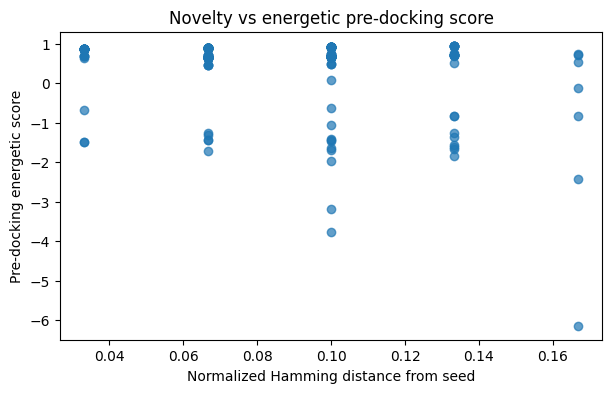

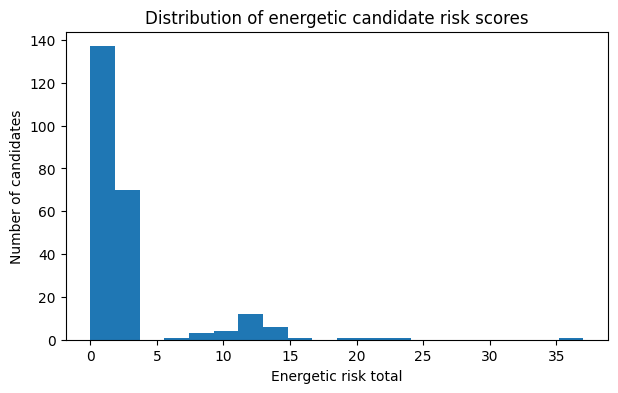

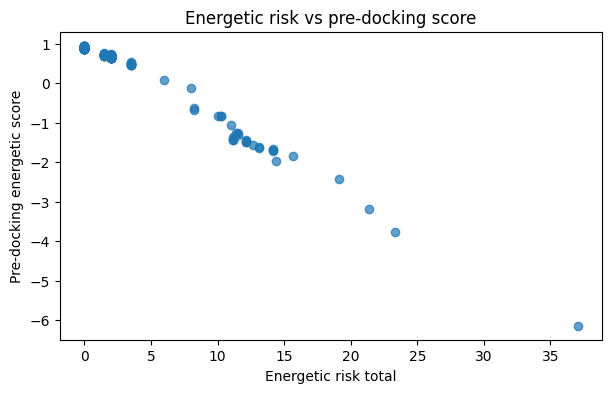

In [10]:
plot_df = candidate_summary[candidate_summary["is_seed"] == False].copy()

plt.figure(figsize=(7, 4))
plt.scatter(plot_df["normalized_hamming"], plot_df["pre_docking_energetic_score"], alpha=0.7)
plt.xlabel("Normalized Hamming distance from seed")
plt.ylabel("Pre-docking energetic score")
plt.title("Novelty vs energetic pre-docking score")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(plot_df["energetic_risk_total"], bins=20)
plt.xlabel("Energetic risk total")
plt.ylabel("Number of candidates")
plt.title("Distribution of energetic candidate risk scores")
plt.show()

plt.figure(figsize=(7, 4))
plt.scatter(plot_df["energetic_risk_total"], plot_df["pre_docking_energetic_score"], alpha=0.7)
plt.xlabel("Energetic risk total")
plt.ylabel("Pre-docking energetic score")
plt.title("Energetic risk vs pre-docking score")
plt.show()


## 10. Position-level mutation profile

Saved: outputs/position_mutation_profile_energetic.csv


,pos_seed,resseq,wt_aa,is_interface,is_energetic_hotspot,n_mutations,n_nonconservative,n_charge_changes,ddG_kcal_mol,mean_energetic_risk
4,5,26,L,True,True,10,0,0,4.158520,12.158520
14,16,37,Y,True,True,10,0,0,4.645860,11.145860
0,0,21,M,True,True,5,0,0,1.749230,8.249230
16,18,39,G,True,True,2,0,0,5.876590,14.376590
20,24,45,R,True,True,2,0,0,2.002810,8.502810
22,26,47,L,True,True,2,0,0,3.543710,11.543710
18,22,43,Q,True,True,1,0,0,2.515570,9.015570
19,23,44,Y,True,True,1,0,0,3.370680,11.370680
7,8,29,Y,False,False,104,1,0,0.000000,0.019231
13,15,36,G,False,False,82,0,0,0.000000,2.000000


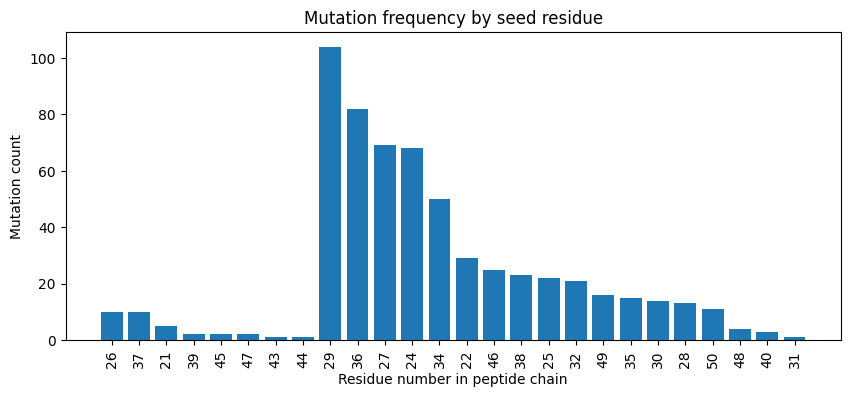

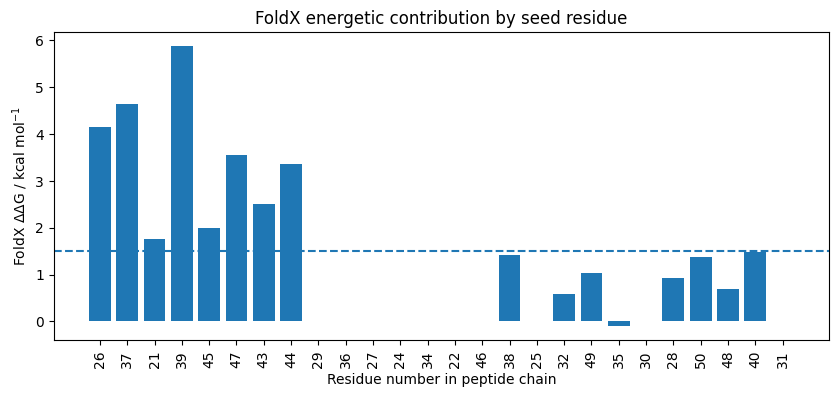

In [11]:
non_seed_mut = mutations_long[
    (mutations_long["is_seed"] == False) &
    (mutations_long["is_mutated"] == True)
].copy()

position_profile = (
    non_seed_mut
    .groupby(["pos_seed", "resseq", "wt_aa", "is_interface", "is_energetic_hotspot"], as_index=False)
    .agg(
        n_mutations=("is_mutated", "count"),
        n_nonconservative=("mutation_class", lambda x: int((x == "non_conservative").sum())),
        n_charge_changes=("charge_change", "sum"),
        ddG_kcal_mol=("ddG_kcal_mol", "mean"),
        mean_energetic_risk=("energetic_risk_points", "mean"),
    )
    .sort_values(["is_energetic_hotspot", "n_mutations"], ascending=[False, False])
)

OUT_POSITION_PROFILE = OUTPUT_DIR / "position_mutation_profile_energetic.csv"
position_profile.to_csv(OUT_POSITION_PROFILE, index=False)

print("Saved:", OUT_POSITION_PROFILE)
display(position_profile)

plt.figure(figsize=(10, 4))
plt.bar(position_profile["resseq"].astype(str), position_profile["n_mutations"])
plt.xlabel("Residue number in peptide chain")
plt.ylabel("Mutation count")
plt.title("Mutation frequency by seed residue")
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(position_profile["resseq"].astype(str), position_profile["ddG_kcal_mol"])
plt.axhline(DDG_HOTSPOT_THRESHOLD, linestyle="--")
plt.xlabel("Residue number in peptide chain")
plt.ylabel("FoldX ΔΔG / kcal mol$^{-1}$")
plt.title("FoldX energetic contribution by seed residue")
plt.xticks(rotation=90)
plt.show()


## 11. Generate compact Markdown report

In [12]:
n_total = len(candidate_summary)
n_generated = int((candidate_summary["is_seed"] == False).sum())
n_high = int((candidate_summary["priority"] == "high_priority").sum())
n_top = int((top_summary["is_seed"] == False).sum())

best_non_seed = top_candidates.iloc[0] if len(top_candidates) else None

report_lines = []
report_lines.append("# Energetic pre-docking validation report")
report_lines.append("")
report_lines.append("## Input")
report_lines.append(f"- Seed residue interval: {PEPTIDE_CHAIN}:{SEED_START_RESSEQ}-{SEED_END_RESSEQ}")
report_lines.append(f"- Seed sequence: `{seed_sequence}`")
report_lines.append(f"- Seed length: {len(seed_sequence)} aa")
report_lines.append(f"- Number of interface positions in seed: {len(interface_positions)}")
report_lines.append(f"- Number of FoldX energetic hotspots in seed: {len(energetic_hotspot_positions)}")
report_lines.append(f"- Hotspot criterion: FoldX alanine scanning ΔΔG > {DDG_HOTSPOT_THRESHOLD} kcal/mol")
report_lines.append("")
report_lines.append("## Candidate set")
report_lines.append(f"- Total candidates including seed: {n_total}")
report_lines.append(f"- Generated candidates: {n_generated}")
report_lines.append(f"- High-priority candidates: {n_high}")
report_lines.append(f"- Candidates exported for downstream validation: {n_top}")
report_lines.append("")
report_lines.append("## Validation logic")
report_lines.append("- FoldX energetic hotspot mutations were strongly penalized.")
report_lines.append("- Non-conservative interface mutations and interface charge changes were penalized.")
report_lines.append("- Mutation risk was scaled by the energetic relevance of the mutated residue when ΔΔG was available.")
report_lines.append("- The final score is a pre-docking prioritization score, not a binding free-energy estimate.")
report_lines.append("")

if best_non_seed is not None:
    report_lines.append("## Top generated candidate")
    report_lines.append(f"- Sequence: `{best_non_seed['sequence']}`")
    report_lines.append(f"- Pre-docking energetic score: {best_non_seed['pre_docking_energetic_score']:.4f}")
    report_lines.append(f"- Diffusion rank score: {best_non_seed['diffusion_rank_score']:.4f}")
    report_lines.append(f"- Mutations: {best_non_seed['mutation_list']}")
    report_lines.append(f"- Energetic risk total: {best_non_seed['energetic_risk_total']:.2f}")
    report_lines.append("")

report_lines.append("## Interpretation")
report_lines.append(
    "This notebook selected diffusion-generated peptide variants that preserve FoldX-derived energetic hotspots "
    "and maintain conservative physicochemical patterns at the interface. These candidates are prioritized for "
    "downstream structural validation and should not be interpreted as confirmed binders."
)
report_lines.append("")

report_text = NL.join(report_lines)

OUT_REPORT = OUTPUT_DIR / "pre_docking_energetic_validation_report.md"
OUT_REPORT.write_text(report_text, encoding="utf-8")

print("Saved:", OUT_REPORT)
print(report_text)


Saved: outputs/pre_docking_energetic_validation_report.md
# Energetic pre-docking validation report

## Input
- Seed residue interval: D:21-50
- Seed sequence: `MYIEALDKYACNCVVGYIGERCQYRDLKWW`
- Seed length: 30 aa
- Number of interface positions in seed: 23
- Number of FoldX energetic hotspots in seed: 11
- Hotspot criterion: FoldX alanine scanning ΔΔG > 1.5 kcal/mol

## Candidate set
- Total candidates including seed: 239
- Generated candidates: 238
- High-priority candidates: 198
- Candidates exported for downstream validation: 10

## Validation logic
- FoldX energetic hotspot mutations were strongly penalized.
- Non-conservative interface mutations and interface charge changes were penalized.
- Mutation risk was scaled by the energetic relevance of the mutated residue when ΔΔG was available.
- The final score is a pre-docking prioritization score, not a binding free-energy estimate.

## Top generated candidate
- Sequence: `MYIDALEKWACNCIVGYIGERCQYRDLKWW`
- Pre-docking energetic scor

## 12. Downstream use

The most important outputs are:

```text
outputs/top_diffusion_energetic_peptides_summary.csv
outputs/top_diffusion_energetic_peptides_pre_docking.fasta
```

Use these for the next structural validation stage:

- ESMFold/ColabFold-like structure prediction;
- peptide conformational modelling;
- docking preparation;
- MD or MM-GBSA/MM-PBSA if available.

Recommended wording:

> Diffusion-generated peptide variants were filtered through an energetic pre-docking validation step that prioritized preservation of FoldX-derived alanine-scanning hotspots and conservative interface substitutions.


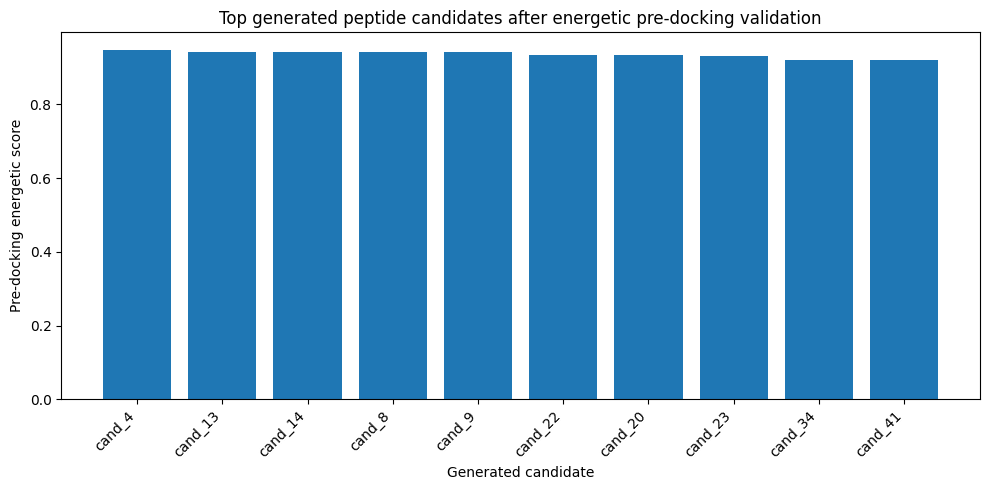

,candidate_index,sequence,mutation_list,pre_docking_energetic_score,energetic_hotspot_preservation,energetic_risk_total,priority
1,4,MYIDALEKWACNCIVGYIGERCQYRDLKWW,"E24D, D27E, Y29W, V34I",0.947798,1.0,0.0,high_priority
4,13,MYIDALEKWACTCVVGYIGERCQYRDLKWW,"E24D, D27E, Y29W, N32T",0.941277,1.0,0.0,high_priority
5,14,MYIDLLEKFACNCVVGYIGERCQYRDLKWW,"E24D, A25L, D27E, Y29F",0.941277,1.0,0.0,high_priority
2,8,MFIDALEKYACSCVVGYIGERCQYRDLKWW,"Y22F, E24D, D27E, N32S",0.941277,1.0,0.0,high_priority
3,9,MWIEALEKFACNCVLGYIGERCQYRDLKWW,"Y22W, D27E, Y29F, V35L",0.941277,1.0,0.0,high_priority
7,22,MYIEALDKWICNCAVGYIGERCQYRDLKFW,"Y29W, A30I, V34A, W49F",0.934755,1.0,0.0,high_priority
6,20,MYIDVLDKYACNCMVGYIGERCQYRDLKWF,"E24D, A25V, V34M, W50F",0.934755,1.0,0.0,high_priority
8,23,MYIEALDKFACNCEVGYIGERCQYRELKFW,"Y29F, V34E, D46E, W49F",0.931421,1.0,0.0,high_priority
14,34,MYIDALEKYACNCIVGYIGERCQYRDLKWW,"E24D, D27E, V34I",0.921306,1.0,0.0,high_priority
18,41,MYIEALEKWACNCLVGYIGERCQYRDLKWW,"D27E, Y29W, V34L",0.921306,1.0,0.0,high_priority


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

val = pd.read_csv("outputs/validated_candidates_pre_docking_energetic.csv")

# Escludo il seed per mostrare solo candidati generati
generated = val[val["is_seed"] == False].copy()

top = generated.sort_values(
    "pre_docking_energetic_score",
    ascending=False
).head(10).copy()

top["candidate_label"] = [
    "cand_" + str(i) for i in top["candidate_index"]
]

plt.figure(figsize=(10, 5))

plt.bar(
    top["candidate_label"],
    top["pre_docking_energetic_score"]
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Pre-docking energetic score")
plt.xlabel("Generated candidate")
plt.title("Top generated peptide candidates after energetic pre-docking validation")

plt.tight_layout()
plt.savefig("outputs/top_candidates_pre_docking_score.png", dpi=300)
plt.show()

display(
    top[
        [
            "candidate_index",
            "sequence",
            "mutation_list",
            "pre_docking_energetic_score",
            "energetic_hotspot_preservation",
            "energetic_risk_total",
            "priority",
        ]
    ]
)

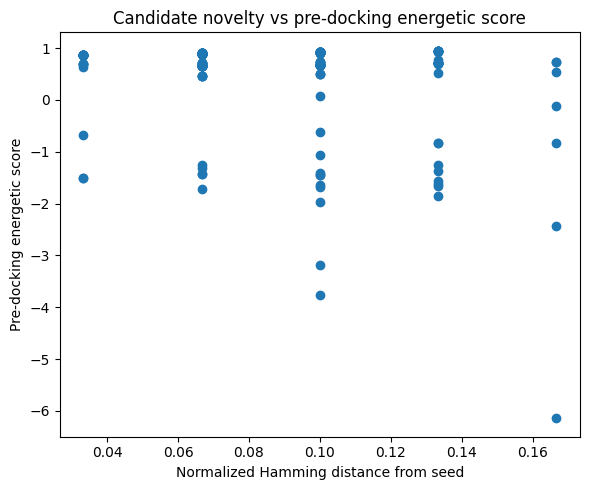

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

val = pd.read_csv("outputs/validated_candidates_pre_docking_energetic.csv")

generated = val[val["is_seed"] == False].copy()

plt.figure(figsize=(6, 5))

plt.scatter(
    generated["normalized_hamming"],
    generated["pre_docking_energetic_score"]
)

plt.xlabel("Normalized Hamming distance from seed")
plt.ylabel("Pre-docking energetic score")
plt.title("Candidate novelty vs pre-docking energetic score")

plt.tight_layout()
plt.savefig("outputs/candidate_novelty_vs_score.png", dpi=300)
plt.show()

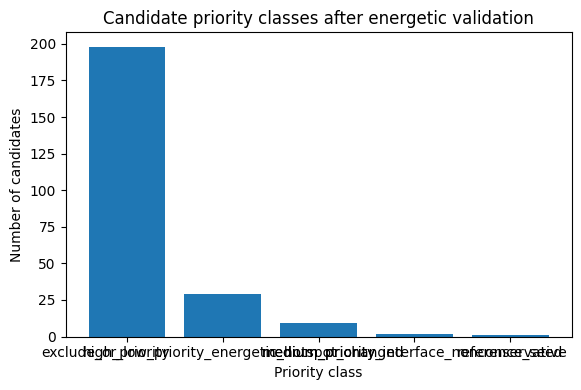

,priority,count
0,high_priority,198
1,exclude_or_low_priority_energetic_hotspot_changed,29
2,medium_priority,9
3,medium_priority_interface_nonconservative,2
4,reference_seed,1


In [15]:
import pandas as pd
import matplotlib.pyplot as plt

val = pd.read_csv("outputs/validated_candidates_pre_docking_energetic.csv")

priority_counts = val["priority"].value_counts().reset_index()
priority_counts.columns = ["priority", "count"]

plt.figure(figsize=(6, 4))

plt.bar(
    priority_counts["priority"],
    priority_counts["count"]
)

plt.ylabel("Number of candidates")
plt.xlabel("Priority class")
plt.title("Candidate priority classes after energetic validation")

plt.tight_layout()
plt.savefig("outputs/candidate_priority_classes.png", dpi=300)
plt.show()

display(priority_counts)

In [16]:
from pathlib import Path

expected_outputs = [
    "outputs/validated_candidates_pre_docking_energetic.csv",
    "outputs/top_diffusion_energetic_peptides_summary.csv",
    "outputs/top_diffusion_energetic_peptides_pre_docking.fasta",
    "outputs/pre_docking_energetic_validation_report.md",
    "outputs/top_candidates_pre_docking_score.png",
    "outputs/candidate_novelty_vs_score.png",
    "outputs/candidate_priority_classes.png",
]

for f in expected_outputs:
    p = Path(f)
    print(f"{f:70} exists={p.exists()} size={p.stat().st_size if p.exists() else 'NA'}")

outputs/validated_candidates_pre_docking_energetic.csv                 exists=True size=60160
outputs/top_diffusion_energetic_peptides_summary.csv                   exists=True size=3241
outputs/top_diffusion_energetic_peptides_pre_docking.fasta             exists=True size=1122
outputs/pre_docking_energetic_validation_report.md                     exists=True size=1369
outputs/top_candidates_pre_docking_score.png                           exists=True size=122246
outputs/candidate_novelty_vs_score.png                                 exists=True size=104946
outputs/candidate_priority_classes.png                                 exists=True size=99199


In [18]:
from pathlib import Path

# ============================================================
# ENERGETIC PRE-DOCKING VALIDATION REPORT
# ============================================================

# Statistiche complessive
n_total = len(candidate_summary)

n_generated = int(
    (candidate_summary["is_seed"] == False).sum()
)

n_high = int(
    (
        candidate_summary["priority"]
        == "high_priority"
    ).sum()
)

n_top = int(
    (top_summary["is_seed"] == False).sum()
)

# Miglior candidato non-seed
best_non_seed = (
    top_candidates.iloc[0]
    if len(top_candidates) > 0
    else None
)

# ============================================================
# COSTRUZIONE DEL REPORT
# ============================================================

report_lines = []

report_lines.append(
    "# Energetic pre-docking validation report"
)

report_lines.append("")

report_lines.append("## Input")

report_lines.append(
    f"- Seed residue interval: "
    f"{PEPTIDE_CHAIN}:{SEED_START_RESSEQ}-{SEED_END_RESSEQ}"
)

report_lines.append(
    f"- Seed sequence: `{seed_sequence}`"
)

report_lines.append(
    f"- Seed length: {len(seed_sequence)} aa"
)

report_lines.append(
    f"- Number of interface positions in seed: "
    f"{len(interface_positions)}"
)

report_lines.append(
    f"- Number of FoldX energetic hotspots in seed: "
    f"{len(energetic_hotspot_positions)}"
)

report_lines.append(
    f"- Hotspot criterion: FoldX alanine scanning "
    f"ΔΔG > {DDG_HOTSPOT_THRESHOLD} kcal/mol"
)

report_lines.append("")

report_lines.append("## Candidate set")

report_lines.append(
    f"- Total candidates including seed: {n_total}"
)

report_lines.append(
    f"- Generated candidates: {n_generated}"
)

report_lines.append(
    f"- High-priority candidates: {n_high}"
)

report_lines.append(
    f"- Candidates exported for downstream validation: {n_top}"
)

report_lines.append("")

report_lines.append("## Validation logic")

report_lines.append(
    "- FoldX energetic hotspot mutations were strongly penalized."
)

report_lines.append(
    "- Non-conservative interface mutations and interface "
    "charge changes were penalized."
)

report_lines.append(
    "- Mutation risk was scaled by the energetic relevance "
    "of the mutated residue when ΔΔG was available."
)

report_lines.append(
    "- Cys/Pro perturbations were included among the "
    "sequence-level risk factors."
)

report_lines.append(
    "- The final score is a pre-docking prioritization score, "
    "not a binding free-energy estimate."
)

report_lines.append("")

# ============================================================
# MIGLIOR CANDIDATO
# ============================================================

if best_non_seed is not None:

    report_lines.append("## Top generated candidate")

    report_lines.append(
        f"- Sequence: `{best_non_seed['sequence']}`"
    )

    report_lines.append(
        f"- Pre-docking energetic score: "
        f"{best_non_seed['pre_docking_energetic_score']:.4f}"
    )

    report_lines.append(
        f"- Diffusion rank score: "
        f"{best_non_seed['diffusion_rank_score']:.4f}"
    )

    report_lines.append(
        f"- Mutations: {best_non_seed['mutation_list']}"
    )

    report_lines.append(
        f"- Energetic risk total: "
        f"{best_non_seed['energetic_risk_total']:.2f}"
    )

    report_lines.append(
        f"- Energetic hotspot mutations: "
        f"{int(best_non_seed['n_energetic_hotspot_mutations'])}"
    )

    report_lines.append(
        f"- Interface non-conservative mutations: "
        f"{int(best_non_seed['n_interface_nonconservative_mutations'])}"
    )

    report_lines.append("")

# ============================================================
# INTERPRETAZIONE
# ============================================================

report_lines.append("## Interpretation")

report_lines.append(
    "This notebook selected diffusion-generated peptide variants "
    "that preserve FoldX-derived energetic hotspots and maintain "
    "conservative physicochemical patterns at the interface. "
    "These candidates are prioritized for downstream structural "
    "validation and should not be interpreted as confirmed binders."
)

report_lines.append("")

# Unisce le righe
report_text = "\n".join(report_lines)

# ============================================================
# SALVATAGGIO
# ============================================================

report_path = (
    OUTPUT_DIR /
    "pre_docking_energetic_validation_report.md"
)

report_path.write_text(
    report_text,
    encoding="utf-8"
)

print(f"Saved: {report_path}")
print()
print(report_text)

Saved: outputs/pre_docking_energetic_validation_report.md

# Energetic pre-docking validation report

## Input
- Seed residue interval: D:21-50
- Seed sequence: `MYIEALDKYACNCVVGYIGERCQYRDLKWW`
- Seed length: 30 aa
- Number of interface positions in seed: 23
- Number of FoldX energetic hotspots in seed: 11
- Hotspot criterion: FoldX alanine scanning ΔΔG > 1.5 kcal/mol

## Candidate set
- Total candidates including seed: 239
- Generated candidates: 238
- High-priority candidates: 198
- Candidates exported for downstream validation: 10

## Validation logic
- FoldX energetic hotspot mutations were strongly penalized.
- Non-conservative interface mutations and interface charge changes were penalized.
- Mutation risk was scaled by the energetic relevance of the mutated residue when ΔΔG was available.
- Cys/Pro perturbations were included among the sequence-level risk factors.
- The final score is a pre-docking prioritization score, not a binding free-energy estimate.

## Top generated candi